# Examine figure stats

This is done after running `create_figures_batch.py`

In [152]:
save_dir = '~/Dropbox/jcdl_followup/synthetic_figures/' # where images are saved

In [153]:
import os
from glob import glob
import json
import pandas as pd

save_dir = os.path.expanduser(save_dir)

In [154]:
# get jsons
img_files = glob(save_dir+'jsons/*.json')
img_files[:3]

['/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/jsons/Picture_000121.json',
 '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/jsons/Picture_000064.json',
 '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/jsons/Picture_000176.json']

In [155]:
npanels = []; ncols=[]; nrows=[]; filenames= []

for imgf in img_files:
    with open(imgf,'r') as f:
        data = json.load(f)
        data = json.loads(data)
    nr = data['figure']['nrows']
    nc = data['figure']['ncols']
    ncols.append(nc);nrows.append(nr)
    npanels.append(nc*nr)
    filenames.append(imgf)

df_figure = pd.DataFrame({'number of panels':npanels, 'number of columns':ncols,
                        'number of rows':nrows,
                        'filename':filenames})

In [156]:
print('there are a total of', len(df_figure), 'figures generated')
print('% of multipanel plots =', len(df_figure[df_figure['number of panels']>1])/len(df_figure)*100,
        '(total of', int(len(df_figure[df_figure['number of panels']>1])),')')

there are a total of 199 figures generated
% of multipanel plots = 41.20603015075377 (total of 82 )


In [159]:
df_figure['number of panels'].value_counts().sort_index()

number of panels
1     117
2      32
3       9
4      17
5       5
6       3
8       8
9       2
12      3
15      2
20      1
Name: count, dtype: int64

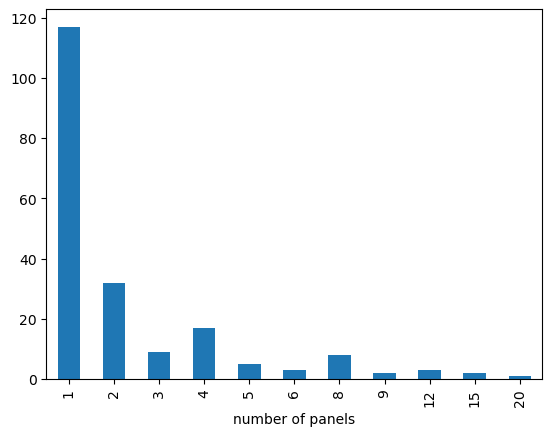

In [161]:
ax = df_figure['number of panels'].value_counts().sort_index().plot(kind='bar')


In [ ]:
# remove a subset of single panel plots?
remove_singles = False
n_remove = 80
df_single_panel = df_figure[df_figure['number of panels'] == 1]
print('there are:', len(df_single_panel), 'single panel plots')
if remove_singles:
    df_s_remove = df_single_panel.sample(n=n_remove, replace=False)
    for i,d in df_s_remove.iterrows():
        #print(d['filename'])
        try:
            os.remove(d['filename'])
        except:
            print('could not remove:', d['filename'])
        try:
            os.remove(d['filename'].replace('/jsons/','/imgs/').removesuffix('.json')+'.jpeg') # also imgs
        except:
            print('could not remove:', d['filename'].replace('/jsons/','/imgs/').removesuffix('.json')+'.jpeg')
        try:
            os.remove(d['filename'].replace('/jsons/','/diags/').removesuffix('.json')+'.jpeg') # also imgs
        except:
            print('could not remove:', d['filename'].replace('/jsons/','/diags/').removesuffix('.json')+'.jpeg')


there are: 124 single panel plots


In [49]:
df_s_remove

,number of panels,number of columns,number of rows,filename
47,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
19,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
195,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
126,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
45,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
...,...,...,...,...
115,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
76,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
107,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
38,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
